In [1]:
# ─────────────────────────────────────────────
# [C1] ⚙️ 데이터 준비
# 최초 1회 다운로드 → data/ 폴더에 저장 (이후 오프라인)
# ─────────────────────────────────────────────
import urllib.request, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

def fetch_uci(url, zip_name, member):
    """UCI 정적 저장소의 zip을 내려받아 data/에 풀고, CSV 경로를 돌려줍니다."""
    csv_path = DATA_DIR / member
    if not csv_path.exists():
        zip_path = DATA_DIR / zip_name
        if not zip_path.exists():
            print(f"내려받는 중… {zip_name}")
            urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path) as z:
            z.extract(member, DATA_DIR)
    return csv_path

shoppers = pd.read_csv(fetch_uci(
    "https://archive.ics.uci.edu/static/public/468/online+shoppers+purchasing+intention+dataset.zip",
    "online_shoppers.zip", "online_shoppers_intention.csv"))

NUM_COLS = ["Administrative", "Administrative_Duration", "Informational",
            "Informational_Duration", "ProductRelated", "ProductRelated_Duration",
            "BounceRates", "ExitRates", "PageValues", "SpecialDay"]

X = shoppers[NUM_COLS]
y = shoppers["Revenue"].astype(int)

print(f"쇼핑 세션 데이터: {shoppers.shape[0]:,}행 × {shoppers.shape[1]}열")
print(f"구매 전환율: {y.mean():.4f}")
print("\n→ 준비 완료. 이제 여러분 차례입니다.")

쇼핑 세션 데이터: 12,330행 × 18열
구매 전환율: 0.1547

→ 준비 완료. 이제 여러분 차례입니다.


[문제 1]
1) train_test_split으로 8:2 분리해 각 모델의 홀드아웃 정확도를 구하세요 (random_state=42).
2) StratifiedKFold(n_splits=5, shuffle=True, random_state=42)로 교차 검증 점수를 구하고,
   평균과 표준편차를 계산하세요.
3) 다섯 모델을 한 표로 만들어 홀드아웃 · CV 평균 · 표준편차 · 둘의 차이를 출력하세요.
   ① Dummy  ② 트리(기본)  ③ 트리(max_depth=5)  ④ RandomForest  ⑤ XGBoost

In [12]:
# [C2] 문제 1. 교차 검증으로 다섯 모델을 다시 잰다
# ⌨️ 문제 1 — 홀드아웃과 계층 5겹 교차 검증을 나란히
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 여기에 코드를 작성하세요 (분리 → 모델별 홀드아웃·CV → 비교표)
RANDOM_STATE = 42

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


candidates = {
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "DecisionTree(max_depth=5)": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
                             random_state=RANDOM_STATE, eval_metric="logloss"),

}

# 베이스라인도 함께 — "이보다 나아야 모델"
dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
print(f"베이스라인(다수 클래스 찍기) 정확도 = {dummy.score(X_test, y_test):.4f}\n")

rows = []
for name, m in candidates.items():
    m.fit(X_train, y_train)
    holdout = m.score(X_test, y_test)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_scores = cross_val_score(m, X, y, cv=cv, scoring="accuracy")
    rows.append({
        "모델": name,
        "Holdout 1회": holdout,
        "CV 평균": cv_scores.mean(),
        "CV 표준편차": cv_scores.std(),
        "CV 보고 형식": f"{cv_scores.mean():.3f} ± {cv_scores.std():.3f}",
        "Holdout − CV": holdout - cv_scores.mean(),
    })
compare = pd.DataFrame(rows)
print()
print(compare.round(4).to_string(index=False))
print(f"Holdout 기준 1위: {compare.loc[compare['Holdout 1회'].idxmax(), '모델']}")
print(f"CV 기준 1위:      {compare.loc[compare['CV 평균'].idxmax(), '모델']}")
print(f"가장 불안정한 모델: {compare.loc[compare['CV 표준편차'].idxmax(), '모델']}"
      f" (± {compare['CV 표준편차'].max():.4f})")

베이스라인(다수 클래스 찍기) 정확도 = 0.8451


                       모델  Holdout 1회  CV 평균  CV 표준편차      CV 보고 형식  Holdout − CV
             DecisionTree      0.8423 0.8537   0.0017 0.854 ± 0.002       -0.0114
DecisionTree(max_depth=5)      0.8942 0.8913   0.0040 0.891 ± 0.004        0.0028
             RandomForest      0.8958 0.8939   0.0064 0.894 ± 0.006        0.0019
                  XGBoost      0.8909 0.8946   0.0048 0.895 ± 0.005       -0.0036
Holdout 기준 1위: RandomForest
CV 기준 1위:      XGBoost
가장 불안정한 모델: RandomForest (± 0.0064)


[문제 2]
1) random_state를 0~9로 바꿔가며 train_test_split을 10번 하고,
   트리(max_depth=5)와 랜덤포레스트의 테스트 정확도를 각각 10개 모으세요.
2) 두 모델의 최소 · 최대 · 폭(최대−최소) · 평균 ± 표준편차를 출력하세요.
3) 지난 순서에서 본 "랜덤포레스트 0.8942 대 XGBoost 0.8877"의 차이 0.0065와
   방금 구한 폭을 비교해, 팀장의 질문에 한 문장으로 답하세요.
🧑‍💼 "0.8942와 0.8877. 이 0.0065 차이로 모델을 바꿀 만합니까? 그리고 데이터를 더 모으면 성능이 오릅니까? 로그를 더 쌓을지 결정해야 합니다."

소수점 셋째 자리 차이는 대개 이야기할 가치가 없습니다. 
모델을 바꿔도 아무런 변화가 없을 겁니다.


In [23]:
scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    m = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
    m.fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("DecisionTreeClassifier(max_depth=5) random_state별 테스트 정확도")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()

DecisionTreeClassifier(max_depth=5) random_state별 테스트 정확도

최소 0.885 / 최대 0.900 → 폭 0.015
평균 0.892 ± 0.004



In [24]:
scores_holdout = []
for seed in range(10):
    Xa, Xb, ya, yb = train_test_split(
        X, y, test_size=0.25, random_state=seed, stratify=y)
    m = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    m.fit(Xa, ya)
    scores_holdout.append(m.score(Xb, yb))

scores_holdout = np.array(scores_holdout)

print("RandomForestClassifier(n_estimators=100) random_state별 테스트 정확도")
print()
print(f"최소 {scores_holdout.min():.3f} / 최대 {scores_holdout.max():.3f}"
      f" → 폭 {scores_holdout.max() - scores_holdout.min():.3f}")
print(f"평균 {scores_holdout.mean():.3f} ± {scores_holdout.std():.3f}")
print()

RandomForestClassifier(n_estimators=100) random_state별 테스트 정확도

최소 0.889 / 최대 0.904 → 폭 0.015
평균 0.896 ± 0.004



[문제 3]
1) learning_curve로 랜덤포레스트의 학습곡선을 구하세요.
   (cv는 문제 1의 5겹, train_sizes는 10%에서 100%까지 6단계)
2) 표본 크기별 학습 점수 · 검증 점수 · 격차를 표로 출력하세요.
3) 두 곡선을 한 그래프에 그리세요.
4) "데이터를 더 모을 가치가 있는가"에 근거와 함께 답하세요.

In [25]:
# [C4] 문제 3. 학습곡선 — 데이터를 더 모을까, 모델을 바꿀까
# ⌨️ 문제 3 — 학습곡선으로 다음 투자를 정하기
from sklearn.model_selection import learning_curve

# 여기에 코드를 작성하세요 (learning_curve → 표본별 표 → 두 곡선 그래프)

model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 6),
    scoring="accuracy",
    n_jobs=-1
)
lc = pd.DataFrame({
    "학습 표본 수": train_sizes.astype(int),
    "학습 점수": train_scores.mean(axis=1),
    "검증 점수": val_scores.mean(axis=1),
})
lc["격차"] = lc["학습 점수"] - lc["검증 점수"]
lc["검증 점수 증가분"] = lc["검증 점수"].diff().fillna(0)
print(lc.round(3).to_string(index=False))
print()

 학습 표본 수  학습 점수  검증 점수    격차  검증 점수 증가분
     986    1.0  0.893 0.107      0.000
    2761    1.0  0.895 0.105      0.002
    4537    1.0  0.896 0.104      0.001
    6312    1.0  0.895 0.105     -0.000
    8088    1.0  0.895 0.104      0.000
    9864    1.0  0.893 0.107     -0.003



C:\Users\tjwls\AppData\Local\Temp\ipykernel_4828\1965620612.py:19: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_4828\1965620612.py:19: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_4828\1965620612.py:19: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_4828\1965620612.py:19: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_4828\1965620612.py:19: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\tjwls\AppData\Local\Temp\ipykernel_4828\1965620612.py:19: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(

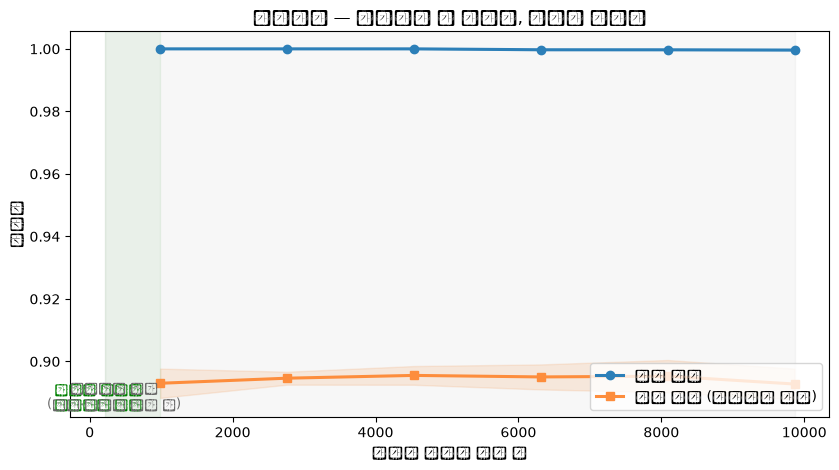

→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.


In [26]:
tr_mean, tr_std = train_scores.mean(axis=1), train_scores.std(axis=1)
va_mean, va_std = val_scores.mean(axis=1), val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.plot(train_sizes, tr_mean, "o-", lw=2.2, color="#2c7fb8", label="학습 점수")
ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, color="#2c7fb8", alpha=0.15)
ax.plot(train_sizes, va_mean, "s-", lw=2.2, color="#fd8d3c", label="검증 점수 (교차검증 평균)")
ax.fill_between(train_sizes, va_mean - va_std, va_mean + va_std, color="#fd8d3c", alpha=0.15)

ax.axvspan(train_sizes[0], 209, color="green", alpha=0.06)
ax.text(120, 0.885, "데이터 추가가\n효과적인 구간", ha="center", fontsize=9, color="green")
ax.axvspan(209, train_sizes[-1], color="gray", alpha=0.06)
ax.text(340, 0.885, "평평해진 구간\n(모델·피처를 바꿀 때)", ha="center", fontsize=9, color="dimgray")

ax.set_xlabel("학습에 사용한 표본 수")
ax.set_ylabel("정확도")
ax.set_title("학습곡선 — 데이터를 더 모을까, 모델을 바꿀까")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("→ 주황 선(검증)의 오른쪽 끝이 평평하면 데이터 추가의 이득이 거의 없다는 뜻입니다.")

4) "데이터를 더 모을 가치가 있는가"에 근거와 함께 답하세요.
가치 하나도 없음. 모델이 이 열 10개로 짜낼 수 있는 것을 이미 다 짜냈다는 뜻

[문제 4]
1) 트리의 max_depth를 [2, 3, 5, 8, 12, None]으로 훑어 CV 평균 ± 표준편차를 표로 만드세요.
   → 교차 검증도 지난 순서와 같은 깊이를 고르는지 확인하세요.
2) 랜덤포레스트의 min_samples_leaf를 [1, 5, 20, 50]으로 훑어
   CV 평균 · 학습 점수 · 학습-테스트 격차를 표로 만드세요.
3) 두 표를 근거로 "어떤 설정을 채택하고 왜인가"를 적으세요.

In [30]:
# [C5] 문제 4. 복잡도 조정으로 격차를 줄인다
# ⌨️ 문제 4 — 교차 검증으로 복잡도 손잡이 고르기

# 여기에 코드를 작성하세요 (max_depth CV 표 → min_samples_leaf CV·격차 표)


depths = [1, 2, 3, 5, 8, 12, None]
rowss = []

for d in depths:
    model_lc = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    result = cross_val_score(model_lc, X, y, cv=cv, scoring="accuracy")
    rowss.append({
        "max_depth": d,
        "CV 평균": result.mean(),
        "CV 표준편차": result.std(),
        "보고 형식": f"{result.mean():.3f} ± {result.std():.3f}",
    })
compare = pd.DataFrame(rowss)
print(compare.round(4).to_string(index=False))
print()

 max_depth  CV 평균  CV 표준편차         보고 형식
       1.0 0.8749   0.0048 0.875 ± 0.005
       2.0 0.8867   0.0077 0.887 ± 0.008
       3.0 0.8879   0.0030 0.888 ± 0.003
       5.0 0.8913   0.0040 0.891 ± 0.004
       8.0 0.8874   0.0026 0.887 ± 0.003
      12.0 0.8773   0.0023 0.877 ± 0.002
       NaN 0.8537   0.0017 0.854 ± 0.002



① 교차 검증도 깊이 5를 골랐습니다. (CV 평균 가장 큼) 지난 순서의 선택이 운은 아니었습니다. 다만 깊이 3(0.8879)·8(0.8876)과의 차이는 0.003~0.004 수준이고 표준편차도 그 정도라, "5가 유일한 정답"이 아니라 "3~8 구간이면 비슷하다" 가 정확한 표현입니다.

In [31]:
min_samples_leaf = [1, 5, 20, 50]
rowss = []
for n in min_samples_leaf:
    tree = RandomForestClassifier(min_samples_leaf=n, random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    result = cross_val_score(tree, X, y, cv=cv, scoring="accuracy")
    tree.fit(X_train, y_train)
    tr = tree.score(X_train, y_train)
    te = tree.score(X_test, y_test)
    rowss.append({
        "min_samples_leaf": n,
        "CV 평균": result.mean(),
        "학습 점수": tr,
        "학습-테스트 격차": tr - te
    })
gap = pd.DataFrame(rowss)
print(gap.round(3).to_string(index=False))
print()


 min_samples_leaf  CV 평균  학습 점수  학습-테스트 격차
                1  0.893  1.000      0.105
                5  0.896  0.952      0.057
               20  0.897  0.918      0.025
               50  0.898  0.906      0.013



② 잎을 크게 만들자 성능이 오히려 올랐습니다. min_samples_leaf를 1에서 20으로 올리자 CV 0.8941 → 0.8941, 격차 0.1056 → 0.0263입니다. 성능과 안정성을 동시에 얻었습니다.

이것이 과적합 처방의 전형입니다. 외우는 것을 막으면 성능이 깎이는 게 아니라, 일반화가 좋아져 오히려 오르는 경우가 많습니다.

In [ ]:
# [C6] 문제 5. 모델 카드 v3 완성 — 오늘의 제출물
# ⌨️ 문제 5 — 검증 결과를 파일로 남기기

# 여기에 코드를 작성하세요 (cv_tbl 등을 CSV로 저장하고 다시 읽어 확인)

